# Домашнее задание к занятию «Работа с переменными»

Выполнил: Ярослав Золотухин

In [159]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [160]:
housing = fetch_california_housing(as_frame=True)
housing.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


Пропуски отсутствуют.

In [161]:
y = housing.target
X = housing.data

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [163]:
model = LinearRegression()
model.fit( X_train, y_train )

LinearRegression()

In [164]:
y_pred = model.predict(X_test)

In [165]:
MSE = mean_squared_error(y_test, y_pred)
RMSE = math.sqrt(MSE)
print(f"RMSE: {RMSE:.4f}")

RMSE: 0.7456


In [166]:
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")

R²: 0.5757877060324508


## График распределения целевой переменной

(array([4489., 7870., 4568., 1991., 1722.]),
 array([0.14999 , 1.119994, 2.089998, 3.060002, 4.030006, 5.00001 ]),
 <BarContainer object of 5 artists>)

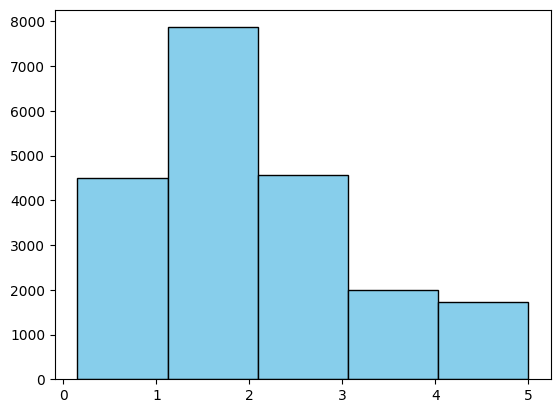

In [167]:
plt.hist(y, bins=5, color='skyblue', edgecolor='black')

{'whiskers': [<matplotlib.lines.Line2D at 0x12b5a8310>,
 'caps': [<matplotlib.lines.Line2D at 0x12b5a8850>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b5a8100>],
 'medians': [<matplotlib.lines.Line2D at 0x12b5a8d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b5b8070>],
 'means': []}

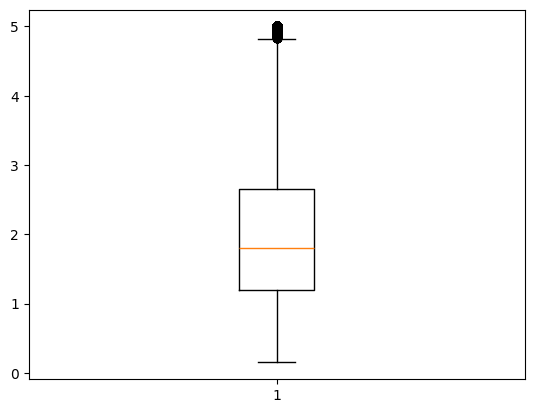

In [168]:
plt.boxplot(y)

Гистограмма и "ящик с усами" построенные по целевой переменной показывают, что выбросы в данных отсутсвуют.

## Построение корреляционной матрицы

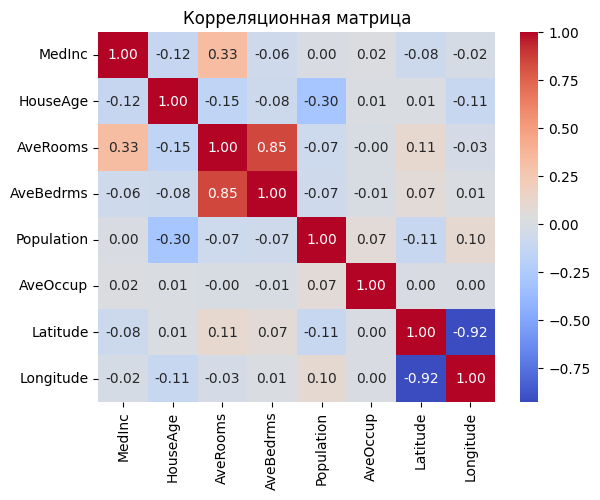

In [169]:
correlation_matrix = X.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

Исходя их матрицы, можно сделать вывод о том, что сильная связь присутствует между такими показателями как "AveBedrms" (т.е. среднее количество спален) и "AveRooms" (т.е. среднее количество комнат в целом) что логично. Также присутствует обратная связь между широтой и долготой.

<br>
Уберем из датасета "AveBedrms" и обучим новую модель.
<br>
P.S. Пробовал убрать и координаты из модели, но стало только хуже, поэтому убрал только один признак.

In [170]:
data_2 = housing.data[ ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude'] ]

data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   Population  20640 non-null  float64
 4   AveOccup    20640 non-null  float64
 5   Latitude    20640 non-null  float64
 6   Longitude   20640 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


Пропусков нет.

In [171]:
X_2 = data_2
y_2 = housing.target

In [172]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [173]:
model_2 = LinearRegression()
model_2.fit( X_train_2, y_train_2 )

LinearRegression()

In [174]:
y_pred_2 = model_2.predict(X_test_2)

In [175]:
MSE_2 = mean_squared_error(y_test_2, y_pred_2)
RMSE_2 = math.sqrt(MSE_2)
print(f"RMSE_2: {RMSE_2:.4f}")

RMSE_2: 0.7398


In [176]:
r2_2 = r2_score(y_test_2, y_pred_2)
print(f"R²_2: {r2_2}")

R²_2: 0.5823239094526445


Значения метрик практически не изменились

## Исследуем оставшиеся признаки на выбросы

### MedInc

(array([2247., 7436., 6098., 2990., 1060.,  428.,  178.,   93.,   47.,
          63.]),
 array([ 0.4999 ,  1.94992,  3.39994,  4.84996,  6.29998,  7.75   ,
         9.20002, 10.65004, 12.10006, 13.55008, 15.0001 ]),
 <BarContainer object of 10 artists>)

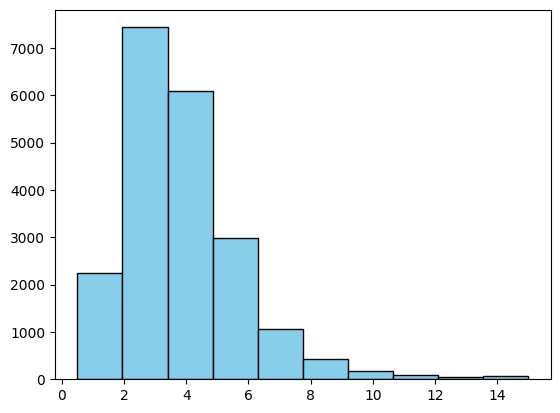

In [177]:
plt.hist(X_2['MedInc'], bins=10, color='skyblue', edgecolor='black')

In [178]:
count_blowout = (X_2['MedInc'] > 10).sum()
count = X_2['MedInc'].sum()
print(count_blowout*100/count)

0.38552696958609656


Исходя из графика мы видим, что значений MedInc более 10 меньше 1%. Соответственно, можем считать их выбросами и уберем их из нашего датасета.

### HouseAge

(array([ 719., 1104., 2235., 2681., 2510., 2354., 3555., 1900., 1616.,
        1966.]),
 array([ 1. ,  6.1, 11.2, 16.3, 21.4, 26.5, 31.6, 36.7, 41.8, 46.9, 52. ]),
 <BarContainer object of 10 artists>)

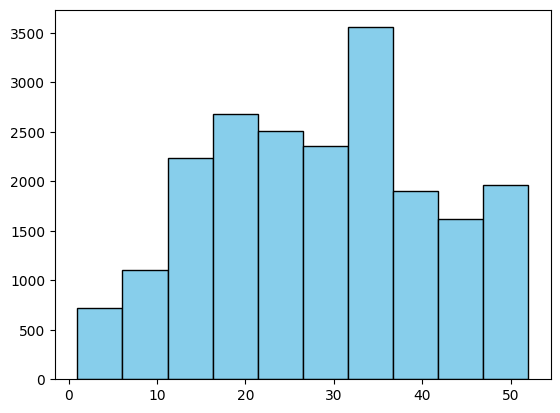

In [179]:
plt.hist(X_2['HouseAge'], bins=10, color='skyblue', edgecolor='black')

Выбросов не выявлено

### AveRooms

{'whiskers': [<matplotlib.lines.Line2D at 0x12b898190>,
 'caps': [<matplotlib.lines.Line2D at 0x12b8986d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b885eb0>],
 'medians': [<matplotlib.lines.Line2D at 0x12b898c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b898eb0>],
 'means': []}

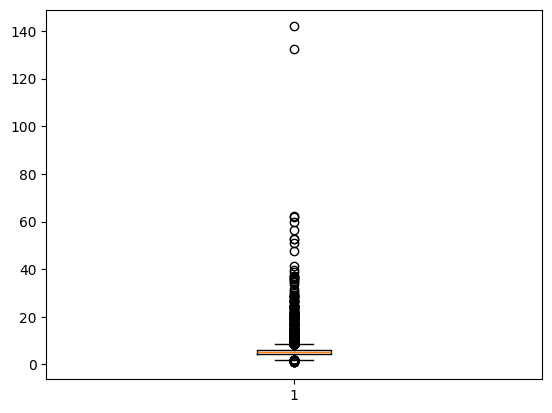

In [180]:
plt.boxplot(X_2['AveRooms'])

Здесь явно видно, что значения более 80 являются выбросами. Уберем их из нашей выборки.

### Population

{'whiskers': [<matplotlib.lines.Line2D at 0x12b90b400>,
 'caps': [<matplotlib.lines.Line2D at 0x12b90b940>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b90b160>],
 'medians': [<matplotlib.lines.Line2D at 0x12b90be80>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b91a160>],
 'means': []}

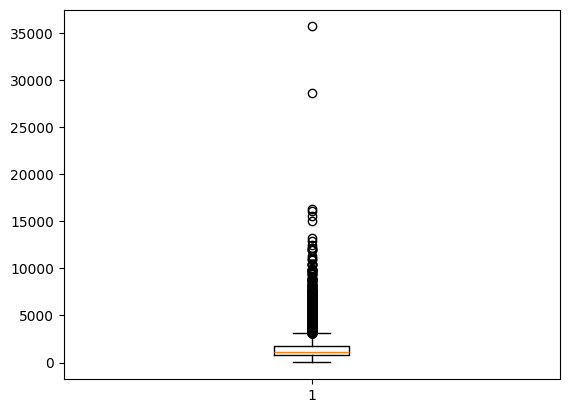

In [181]:
plt.boxplot(X_2['Population'])

Для данной переменной можем сделать вывод о том, что значения более 20000 являются выбросами.

###  AveOccup

{'whiskers': [<matplotlib.lines.Line2D at 0x12b975c10>,
 'caps': [<matplotlib.lines.Line2D at 0x12b986190>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b975970>],
 'medians': [<matplotlib.lines.Line2D at 0x12b9866d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b986970>],
 'means': []}

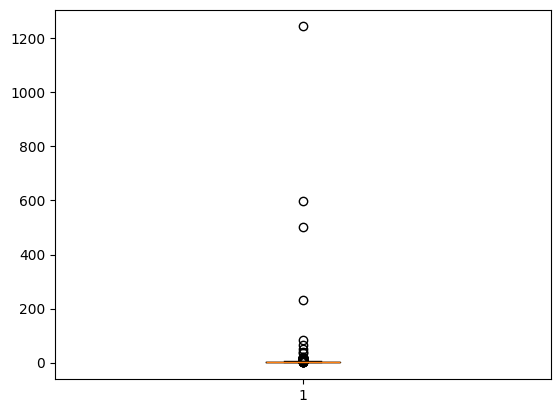

In [182]:
plt.boxplot(X_2['AveOccup'])

Для данной переменной значения больше 200 являются выбросами.

### Убираем выбросы из датасета

In [183]:
# убираем значения MedInc больше 10
X_3 = X_2[X_2['MedInc'] < 10]
y_3 = y_2[X_2['MedInc'] < 10]
# убираем значения AveRooms больше 80
X_3 = X_3[X_3['AveRooms'] < 80]
y_3 = y_3[X_2['AveRooms'] < 80]
# убираем значения Population больше 20 000

X_3 = X_3[X_3['Population'] < 20000]
y_3 = y_3[X_2['Population'] < 20000]
# убираем значения AveOccup больше 200

X_3 = X_3[X_3['AveOccup'] < 200]
y_3 = y_3[X_2['AveOccup'] < 200]
X_3.info()
y_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20324 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20324 non-null  float64
 1   HouseAge    20324 non-null  float64
 2   AveRooms    20324 non-null  float64
 3   Population  20324 non-null  float64
 4   AveOccup    20324 non-null  float64
 5   Latitude    20324 non-null  float64
 6   Longitude   20324 non-null  float64
dtypes: float64(7)
memory usage: 1.2 MB
<class 'pandas.core.series.Series'>
Index: 20324 entries, 0 to 20639
Series name: MedHouseVal
Non-Null Count  Dtype  
--------------  -----  
20324 non-null  float64
dtypes: float64(1)
memory usage: 317.6 KB


### Построим модель на даннных без выбросов

In [184]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [185]:
model_3 = LinearRegression()
model_3.fit( X_train_3, y_train_3 )

LinearRegression()

In [186]:
y_pred_3 = model_3.predict(X_test_3)

In [187]:
MSE_3 = mean_squared_error(y_test_3, y_pred_3)
RMSE_3 = math.sqrt(MSE_3)
print(f"RMSE_3: {RMSE_3:.4f}")

RMSE_3: 0.7138


In [188]:
r2_3 = r2_score(y_test_3, y_pred_3)
print(f"R²_3: {r2_3}")

R²_3: 0.5967076919696694


Значения метрик практически остались такими же

## Математические преобразования над признаками

Возьмем логарифм от признака "MedInc" в связи с ассиметрией распределения (видно из гистограммы выше).

In [189]:
X_4 = X_3
y_4 = y_3
X_4['MedInc'] = np.log(X_4['MedInc'])

In [190]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

In [191]:
model_4 = LinearRegression()
model_4.fit( X_train_4, y_train_4 )

LinearRegression()

In [192]:
y_pred_4 = model_4.predict(X_test_4)

In [193]:
MSE_4 = mean_squared_error(y_test_4, y_pred_4)
RMSE_4 = math.sqrt(MSE_4)
print(f"RMSE_4: {RMSE_4:.4f}")

RMSE_4: 0.7536


In [194]:
r2_4 = r2_score(y_test_4, y_pred_4)
print(f"R²_3: {r2_4}")

R²_3: 0.5504302074633578


# Вывод по проделанной работе

В ходе данного домашнего задания был проведен ряд обработки данных для получения более качественной модели линейной регрессии, а именно:

1. Построена модель на основе всех неизмененных признаков
2. Модель на основе признаков, отобранных по значениям корреляций (убрали признак AveBedrms)
3. Модель без AveBedrms, с чисткой датасета от выбросов
4. Модель с математической обработкой признака MedInd (взят натуральный логарифм)

Полученнные метрики моделей представлены ниже:

| Модель | RMSE | R^2 |
|--------|------|--------|
| На основе всех неизмененных признаков | 0.7456 | 0.5757 |
| На основе признаков, отобранных по значениям корреляций | 0.7398 | 0.5823 |
| Модель без AveBedrms, с чисткой датасета от выбросов | 0.7138 | 0.5967 |
| Модель с математической обработкой признака MedInd (взят натуральный логарифм) | 0.7536 | 0.5504 |


К сожалению, ни один из подходов не дал существенного улучшения качества модели. Возможно, связь признаков и целевой переменной нелинейна и необходимо использовать другие математические модели.
